# AI-Based MCU Selection, Configuration


In [ ]:
import pandas as pd
import numpy as np
import json, time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import random


In [ ]:
# Generate large synthetic MCU dataset
data = []
for _ in range(2000):
    ram = random.choice([2,4,8,16,32,64])
    flash = random.choice([16,32,64,128,256,512])
    uart = random.randint(0,4)
    i2c = random.randint(0,3)
    spi = random.randint(0,3)
    power = random.randint(3,7)
    gpio = random.randint(10,60)
    clock = random.choice([8,16,32,48,72])

    selected = 1 if (ram >= 8 and flash >= 32 and uart >= 1 and power <= 5) else 0
    data.append([ram, flash, uart, i2c, spi, power, gpio, clock, selected])

columns = ['RAM_KB','FLASH_KB','UART','I2C','SPI','POWER','GPIO','CLOCK_MHZ','Selected']
df = pd.DataFrame(data, columns=columns)
df.head()


,RAM_KB,FLASH_KB,UART,I2C,SPI,POWER,GPIO,CLOCK_MHZ,Selected
0,32,16,2,2,1,3,57,8,0
1,16,128,0,0,3,3,52,8,0
2,4,256,1,0,2,6,57,8,0
3,8,64,2,0,3,6,54,48,0
4,4,16,4,2,2,4,43,48,0


In [ ]:
X = df.drop('Selected', axis=1)
y = df['Selected']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


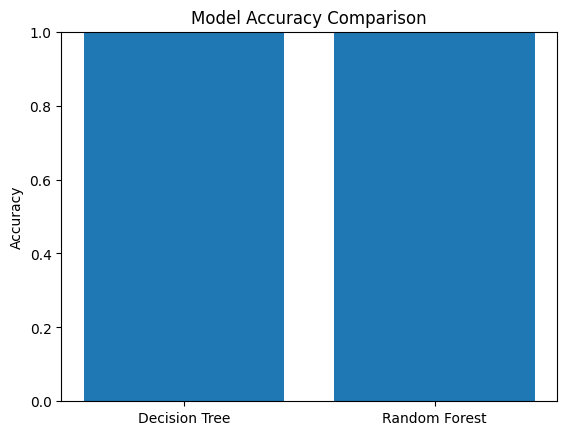

In [ ]:
dt_acc = accuracy_score(y_test, dt.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print('Decision Tree Accuracy:', dt_acc)
print('Random Forest Accuracy:', rf_acc)

plt.bar(['Decision Tree','Random Forest'], [dt_acc, rf_acc])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()


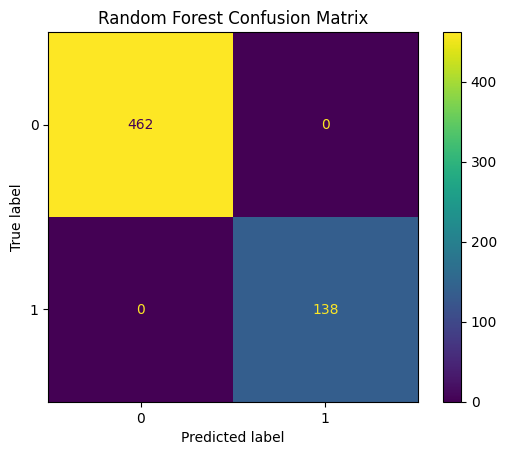

In [ ]:
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()


In [ ]:
user_input = pd.DataFrame([{
    'RAM_KB':16,
    'FLASH_KB':64,
    'UART':2,
    'I2C':1,
    'SPI':1,
    'POWER':4,
    'GPIO':30,
    'CLOCK_MHZ':32
}])

prediction = rf.predict(user_input)
print('Prediction:', 'Suitable MCU' if prediction[0]==1 else 'Not Suitable MCU')


Prediction: Suitable MCU


In [ ]:
config = user_input.iloc[0].to_dict()
print(json.dumps(config, indent=4))

print('--- Virtual MCU Simulation Start ---')
time.sleep(1)
for i in range(3):
    print(f'[UART OUTPUT] Sensor Reading {i+1}: {25+i} °C')
    time.sleep(1)
print('--- Simulation End ---')


{
    "RAM_KB": 16,
    "FLASH_KB": 64,
    "UART": 2,
    "I2C": 1,
    "SPI": 1,
    "POWER": 4,
    "GPIO": 30,
    "CLOCK_MHZ": 32
}
--- Virtual MCU Simulation Start ---
[UART OUTPUT] Sensor Reading 1: 25 °C
[UART OUTPUT] Sensor Reading 2: 26 °C
[UART OUTPUT] Sensor Reading 3: 27 °C
--- Simulation End ---


In [ ]:
with open('ai_selected_mcu_config.json','w') as f:
    json.dump(config, f, indent=4)
print('Configuration saved')


Configuration saved
